# Student Identity

- **Nama**: Siti Alqia Tonggiroh
- **Student ID**: REAENG12MTRGV
- **Batch**: AI Engineering Batch 12
- **Google Drive Folder (public)**: https://drive.google.com/drive/folders/1FzThr3_d1nSxM94h92ksczBmFFghS3-5?usp=sharing


> **Catatan Metodologi (baca sebelum lanjut):**
> Project ini bekerja dengan cara mempelajari pola di sekitar lokasi kafe-kafe yang sudah beroperasi saat ini, lalu membandingkannya dengan area lain.
>
>Karena itu, Skor Kecocokan dalam analisis ini mengukur seberapa mirip karakter suatu lokasi dengan lokasi kafe yang sudah ada. Skor ini tidak menggambarkan perkiraan omzet, keuntungan, atau jaminan kesuksesan bisnis secara langsung.


In [1]:
!pip install osmnx geopandas shap folium scikit-learn xgboost matplotlib seaborn -q


In [2]:
# Data
import pandas as pd
import numpy as np
import random

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Geospasial
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
)

# Explainable AI
import shap

# Peta interaktif
import folium

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Wilayah studi & sistem koordinat metrik
PLACE_NAME = "Bandung, West Java, Indonesia"
CRS_METRIC = 32748          # UTM zone 48S — satuan meter, tepat untuk Bandung
CRS_LATLON = 4326           # untuk visualisasi peta

print("OSMnx    :", ox.__version__)
print("GeoPandas:", gpd.__version__)
print("Wilayah  :", PLACE_NAME)

OSMnx    : 2.1.1
GeoPandas: 1.1.4
Wilayah  : Bandung, West Java, Indonesia


## 2. Pengambilan Data OpenStreetMap

Semua data ditarik dari OpenStreetMap (lisensi terbuka ODbL).

In [3]:
# Sampel positif: coffee shop existing
cafes_raw = ox.features_from_place(
    PLACE_NAME,
    {"amenity": "cafe", "shop": "coffee"}
)

# Ekosistem komersial (sinyal keramaian)
restaurants_raw = ox.features_from_place(PLACE_NAME, {"amenity": "restaurant"})
fast_food_raw   = ox.features_from_place(PLACE_NAME, {"amenity": "fast_food"})

# Generator keramaian
universities_raw = ox.features_from_place(PLACE_NAME, {"amenity": "university"})
malls_raw        = ox.features_from_place(PLACE_NAME, {"shop": "mall"})

roads_raw = ox.features_from_place(PLACE_NAME, {"highway": ["primary", "trunk"]})

print("Coffee shop :", len(cafes_raw))
print("Restoran    :", len(restaurants_raw))
print("Fast food   :", len(fast_food_raw))
print("Universitas :", len(universities_raw))
print("Mall        :", len(malls_raw))
print("Ruas jalan  :", len(roads_raw))

Coffee shop : 480
Restoran    : 1024
Fast food   : 242
Universitas : 77
Mall        : 32
Ruas jalan  : 1740


In [4]:
cafes_raw[["name", "geometry"]].head(10)

name                    geometry
element id                                                            
node    1746761936               Starbucks   POINT (107.6055 -6.89397)
        1956516949               SPBU Dago    POINT (107.62088 -6.869)
        2496127739  Kopi Saring Sinar Pagi  POINT (107.62089 -6.90698)
        3421238301    Habenagen Coffeeshop  POINT (107.60406 -6.90213)
        3428599973            Point Coffee  POINT (107.62022 -6.90608)
        3429603356         The Oldway Cafe  POINT (107.62306 -6.90704)
        3797908134             Kabut Salju  POINT (107.61433 -6.91831)
        3806721281               Cokotetra  POINT (107.61684 -6.87848)
        3806721325                YUTAKANA  POINT (107.61472 -6.88345)
        3807746637                   Vcafe   POINT (107.6209 -6.86814)

## 3. Standardisasi Proyeksi (CRS)

Semua data diproyeksikan ke **EPSG:32748 (UTM 48S)** supaya perhitungan jarak
benar-benar dalam satuan meter (bukan derajat), dan geometry non-titik
(polygon bangunan) disederhanakan menjadi centroid agar konsisten sebagai titik.


In [5]:
# --- Bersihkan & proyeksikan seluruh layer ke CRS metrik (EPSG:32748) ---

def to_point_projected(gdf_raw, crs_metric):
    g = gdf_raw.copy().set_crs(4326, allow_override=True).to_crs(epsg=crs_metric)
    g["geometry"] = g.geometry.centroid
    return g

# Batas wilayah Bandung, dipakai untuk sampling titik acak & grid prediksi
polygon = ox.geocode_to_gdf(PLACE_NAME).to_crs(epsg=CRS_METRIC).geometry.iloc[0]

cafes         = to_point_projected(cafes_raw, CRS_METRIC)
restaurants   = to_point_projected(restaurants_raw, CRS_METRIC)
fast_food     = to_point_projected(fast_food_raw, CRS_METRIC)
universities  = to_point_projected(universities_raw, CRS_METRIC)
malls         = to_point_projected(malls_raw, CRS_METRIC)

# roads_raw sekarang sudah cuma berisi primary/trunk (difilter langsung saat
# fetch di atas), jadi tinggal reproject ke CRS metrik.
main_roads = roads_raw.set_crs(4326, allow_override=True).to_crs(epsg=CRS_METRIC)

print("cafes        :", len(cafes))
print("restaurants  :", len(restaurants))
print("fast_food    :", len(fast_food))
print("universities :", len(universities))
print("malls        :", len(malls))
print("main_roads   :", len(main_roads))


cafes        : 480
restaurants  : 1024
fast_food    : 242
universities : 77
malls        : 32
main_roads   : 1740


## 4. Feature Engineering — Fungsi Perhitungan Fitur

Bagian ini berisi fungsi pembantu untuk menghitung fitur spasial, seperti jumlah kompetitor di radius tertentu dan jarak ke fasilitas terdekat. Fungsi ini dipakai secara konsisten di seluruh tahap analisis—mulai dari penyiapan data latih (positif & negatif) hingga pembuatan grid prediksi di akhir notebook.


In [6]:
def count_within_radius(points_gs, poi_gdf, radius, exclude_self=False):
    """Hitung jumlah POI dalam radius tertentu.

    Set exclude_self=True untuk data eksisting agar tidak terjadi self-counting.
    """
    sindex = poi_gdf.sindex
    counts = []
    for point in points_gs:
        possible = list(sindex.intersection(point.buffer(radius).bounds))
        if possible:
            nearby = poi_gdf.iloc[possible]
            c = int(nearby.geometry.distance(point).le(radius).sum())
        else:
            c = 0
        if exclude_self:
            c = max(c - 1, 0)
        counts.append(c)
    return counts


def distance_to_nearest(points_gs, poi_gdf):
    """Jarak (meter) ke POI titik terdekat."""
    union = poi_gdf.geometry.union_all()
    return [point.distance(union) for point in points_gs]


def distance_to_lines(points_gdf, lines_gdf):
    joined = gpd.sjoin_nearest(
        points_gdf[["geometry"]],
        lines_gdf[["geometry"]],
        how="left",
        distance_col="_jarak",
    )
    # sjoin_nearest bisa menghasilkan baris ganda bila ada jarak yang seri
    joined = joined[~joined.index.duplicated(keep="first")]
    return joined.loc[points_gdf.index, "_jarak"].values


# Daftar fitur
FEATURES = [
    "competitor_500m",          # jumlah coffee shop lain dalam 500 m
    "restaurant_500m",          # jumlah restoran dalam 500 m
    "fastfood_500m",            # jumlah fast food dalam 500 m
    "distance_to_university",   # jarak ke kampus terdekat (m)
    "distance_to_mall",         # jarak ke mall terdekat (m)
    "distance_to_primary_road", # jarak ke jalan utama terdekat (m)
]

def build_features(gdf, is_cafe=False):
    """Ekstraksi seluruh fitur spasial untuk daftar koordinat/point."""
    g = gdf.copy().reset_index(drop=True)
    g["competitor_500m"]          = count_within_radius(g.geometry, cafes, 500, exclude_self=is_cafe)
    g["restaurant_500m"]          = count_within_radius(g.geometry, restaurants, 500)
    g["fastfood_500m"]            = count_within_radius(g.geometry, fast_food, 500)
    g["distance_to_university"]   = distance_to_nearest(g.geometry, universities)
    g["distance_to_mall"]         = distance_to_nearest(g.geometry, malls)
    g["distance_to_primary_road"] = distance_to_lines(g, main_roads)
    return g

print("Fitur yang akan dipertimbangkan:")
for f in FEATURES:
    print(" -", f)

Fitur yang akan dipertimbangkan:
 - competitor_500m
 - restaurant_500m
 - fastfood_500m
 - distance_to_university
 - distance_to_mall
 - distance_to_primary_road


## 5. Sampel Positif — Lokasi Coffee Shop Existing

In [7]:
positive_sites = build_features(cafes, is_cafe=True)
positive_sites["target"] = 1

print("Jumlah sampel positif:", len(positive_sites))
positive_sites[["name"] + FEATURES].head()

Jumlah sampel positif: 480


,name,competitor_500m,restaurant_500m,fastfood_500m,distance_to_university,distance_to_mall,distance_to_primary_road
0,Starbucks,17,43,16,217.017272,26.521855,152.749832
1,SPBU Dago,4,10,1,73.820886,2670.638319,25.581252
2,Kopi Saring Sinar Pagi,27,37,3,520.056529,955.847229,636.424767
3,Habenagen Coffeeshop,7,32,0,446.840125,575.838167,27.785898
4,Point Coffee,30,39,4,402.374381,882.503243,534.820506


## 6. Sampel Negatif — Titik Acak (Pseudo-Absence)
titik acak yang jaraknya < 150 m dari cafe existing dibuang.

In [8]:
minx, miny, maxx, maxy = polygon.bounds
cafes_union = cafes.geometry.union_all()

N_NEGATIVE = 500
MIN_DIST_FROM_CAFE = 150  # meter

random_points = []
attempts = 0
while len(random_points) < N_NEGATIVE and attempts < 200_000:
    attempts += 1
    p = Point(random.uniform(minx, maxx), random.uniform(miny, maxy))
    if not polygon.contains(p):
        continue
    if p.distance(cafes_union) < MIN_DIST_FROM_CAFE:
        continue          # terlalu dekat cafe existing -> buang
    random_points.append(p)

negative_sites = gpd.GeoDataFrame(geometry=random_points, crs=f"EPSG:{CRS_METRIC}")
print(f"Titik negatif terkumpul: {len(negative_sites)} (dari {attempts} percobaan)")

Titik negatif terkumpul: 500 (dari 1015 percobaan)


In [9]:
negative_sites = build_features(negative_sites, is_cafe=False)
negative_sites["target"] = 0

negative_sites[FEATURES].head()

,competitor_500m,restaurant_500m,fastfood_500m,distance_to_university,distance_to_mall,distance_to_primary_road
0,0,0,0,3461.792543,2914.091049,449.229080
1,0,0,0,1947.744787,1829.368156,240.073166
2,0,2,0,753.086566,1065.654703,426.863350
3,0,0,0,2156.040658,3393.092170,783.691420
4,2,9,1,1010.459608,390.244244,259.040111


## 7. Dataset Final

In [10]:
dataset = pd.concat(
    [positive_sites[FEATURES + ["target"]],
     negative_sites[FEATURES + ["target"]]],
    ignore_index=True
)

print("Ukuran dataset:", dataset.shape)
print("\nDistribusi target:")
print(dataset["target"].value_counts())
print("\nProporsi positif: {:.1%}".format(dataset["target"].mean()))
dataset.head()

Ukuran dataset: (980, 7)

Distribusi target:
target
0    500
1    480
Name: count, dtype: int64

Proporsi positif: 49.0%


,competitor_500m,restaurant_500m,fastfood_500m,distance_to_university,distance_to_mall,distance_to_primary_road,target
0,17,43,16,217.017272,26.521855,152.749832,1
1,4,10,1,73.820886,2670.638319,25.581252,1
2,27,37,3,520.056529,955.847229,636.424767,1
3,7,32,0,446.840125,575.838167,27.785898,1
4,30,39,4,402.374381,882.503243,534.820506,1


In [11]:
# Cek nilai kosong
print("Nilai kosong per kolom:")
print(dataset.isna().sum())

Nilai kosong per kolom:
competitor_500m             0
restaurant_500m             0
fastfood_500m               0
distance_to_university      0
distance_to_mall            0
distance_to_primary_road    0
target                      0
dtype: int64


## 8. EDA

In [12]:
dataset.groupby("target")[FEATURES].mean().T.rename(
    columns={0: "Lokasi negatif", 1: "Lokasi cafe existing"}
)

target,Lokasi negatif,Lokasi cafe existing
competitor_500m,1.258000,13.008333
restaurant_500m,2.734000,25.293750
fastfood_500m,0.734000,5.495833
distance_to_university,1595.777321,664.678992
distance_to_mall,1751.827750,806.878673
distance_to_primary_road,597.038390,275.355550


/tmp/ipykernel_15145/611727292.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Negatif (0)", "Cafe (1)"])
/tmp/ipykernel_15145/611727292.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Negatif (0)", "Cafe (1)"])
/tmp/ipykernel_15145/611727292.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Negatif (0)", "Cafe (1)"])
/tmp/ipykernel_15145/611727292.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Negatif (0)", "Cafe (1)"])
/tmp/ipykernel_15145/611727292.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() 

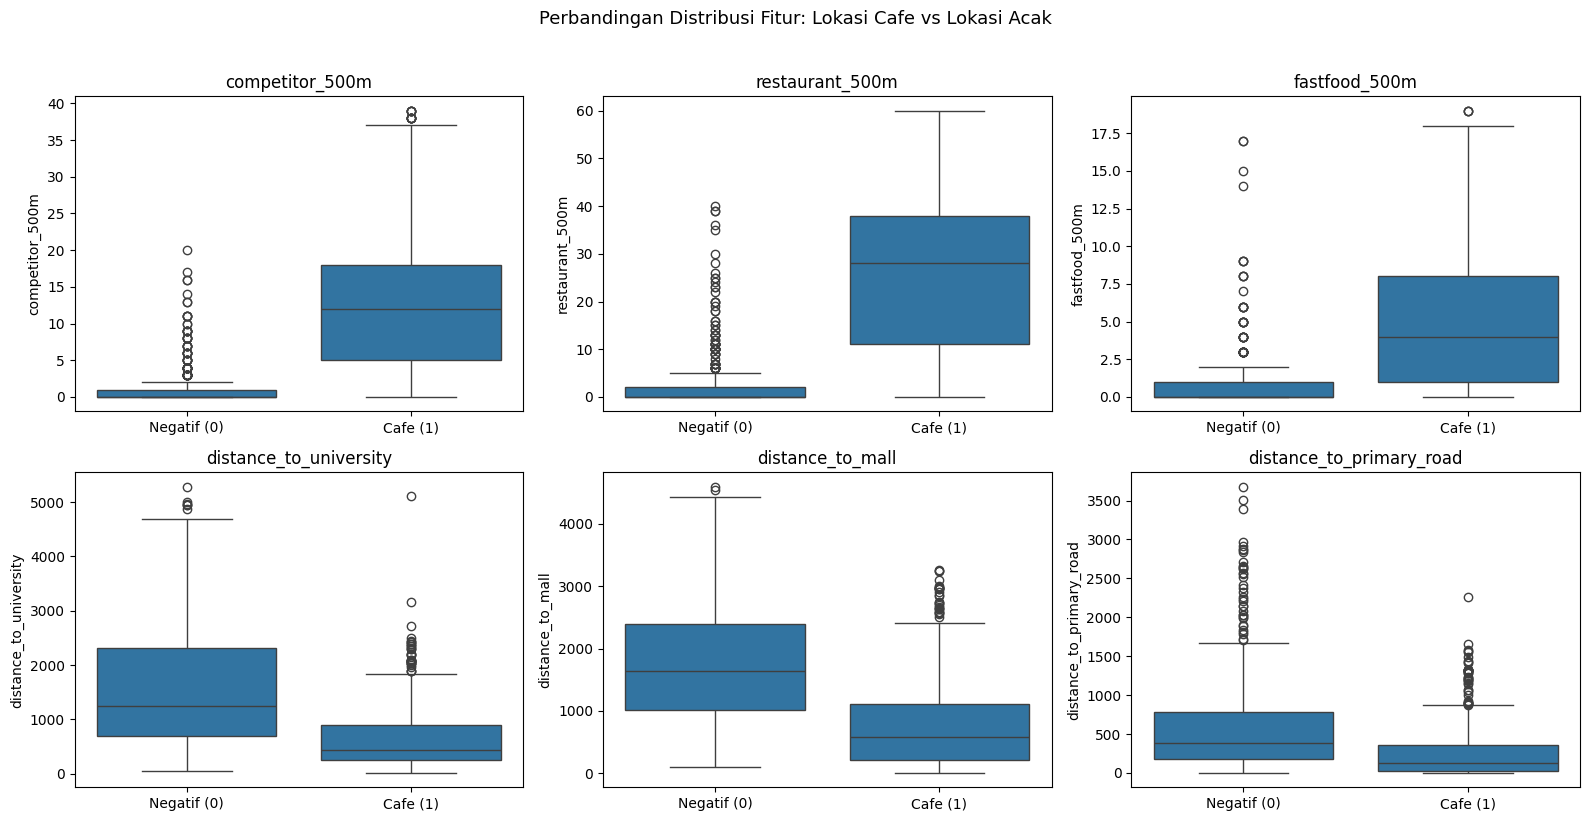

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.boxplot(data=dataset, x="target", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_xticklabels(["Negatif (0)", "Cafe (1)"])
plt.suptitle("Perbandingan Distribusi Fitur: Lokasi Cafe vs Lokasi Acak", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

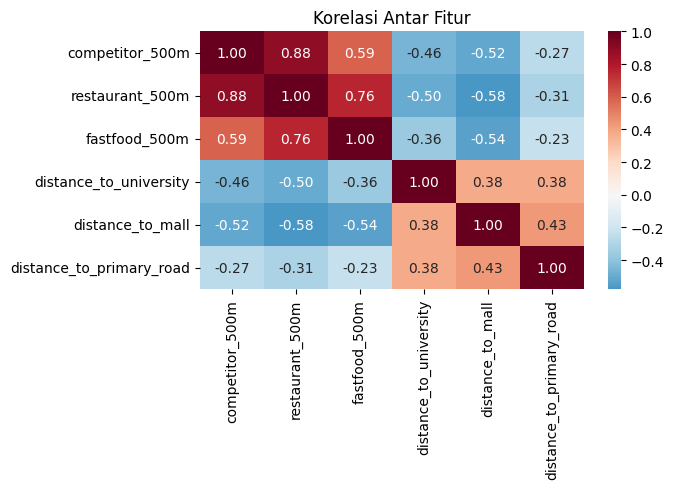

In [14]:
plt.figure(figsize=(7, 5))
sns.heatmap(dataset[FEATURES].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Korelasi Antar Fitur")
plt.tight_layout()
plt.show()

## 9. Training Random Forest

Model utama yang dipilih adalah **Random Forest**, dikonfirmasi lewat
perbandingan baseline (Logistic Regression vs Random Forest vs XGBoost) di
bagian 10b. Data dibagi 80/20 secara *stratified* agar proporsi kelas
(cocok/tidak cocok) tetap terjaga di data latih maupun data uji.


In [15]:
X = dataset[FEATURES]
y = dataset["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f"Data latih: {len(X_train)}  (positif: {y_train.sum()})")
print(f"Data uji  : {len(X_test)}  (positif: {y_test.sum()})")

Data latih: 784  (positif: 384)
Data uji  : 196  (positif: 96)


In [16]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model selesai diltih.")

Model selesai diltih.


## 10. Evaluasi Model

Yang diperiksa:
1. **Classification report** — precision, recall, f1 per kelas
2. **AUC-ROC** — kemampuan model memisahkan lokasi cocok vs tidak
3. **Perbandingan skor latih vs uji** — indikator overfitting
4. **Cross-validation** — konsistensi performa lintas subset data

In [17]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Tidak cocok", "Cocok"]))

print("AUC-ROC:", round(roc_auc_score(y_test, y_proba), 4))

=== Classification Report ===
              precision    recall  f1-score   support

 Tidak cocok       0.88      0.91      0.89       100
       Cocok       0.90      0.86      0.88        96

    accuracy                           0.89       196
   macro avg       0.89      0.89      0.89       196
weighted avg       0.89      0.89      0.89       196

AUC-ROC: 0.9675


Cara Membaca Skor AUC 0.97:
>1. Bukan Prediksi Omzet: Skor ini tidak menjamin kafe akan sukses secara bisnis.
>2. Alasan Skor Tinggi: Model hanya belajar membedakan lokasi kafe yang ada saat ini dari titik-titik acak (termasuk area sepi/lahan kosong). Tugas membedakan dua kondisi ekstrem ini memang cenderung mudah.
>3. Langkah Selanjutnya: Skor tinggi ini perlu divalidasi ulang lewat uji spasial di bawah untuk mengantisipasi potensi kebocoran data (spatial leakage).

In [18]:
# Cek overfitting: bandingkan performa data latih vs data uji
auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
auc_test  = roc_auc_score(y_test, y_proba)

print(f"AUC data latih : {auc_train:.4f}")
print(f"AUC data uji   : {auc_test:.4f}")
print(f"Selisih        : {auc_train - auc_test:.4f}")

if auc_train - auc_test > 0.15:
    print("\n>> Indikasi OVERFITTING: turunkan max_depth atau naikkan min_samples_leaf.")
else:
    print("\n>> Selisih wajar — model tidak menunjukkan overfitting berarti.")

AUC data latih : 0.9804
AUC data uji   : 0.9675
Selisih        : 0.0129

>> Selisih wajar — model tidak menunjukkan overfitting berarti.


In [19]:
# Cross-validation 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")

print("AUC tiap fold:", np.round(cv_scores, 4))
print(f"Rata-rata AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

AUC tiap fold: [0.9236 0.9064 0.9489 0.9605 0.9605]
Rata-rata AUC: 0.9400 (+/- 0.0215)


## 10b. Perbandingan Model (Baseline vs Random Forest vs XGBoost)

Pemilihan Random Forest (RF) didasarkan pada pengujian terukur terhadap dua model pembanding:
>Logistic Regression: Model linear sederhana sebagai baseline. Jika performa RF tidak berbeda jauh, maka penggunaan model yang lebih kompleks tidak terjustifikasi.

>XGBoost: Algoritma gradient boosting yang umumnya unggul untuk data tabular.
Seluruh model dievaluasi menggunakan 5-Fold Stratified Cross-Validation (AUC) agar hasilnya adil dan tidak bergantung pada satu skenario split data saja.


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier

# Logistic Regression butuh scaling; dibungkus pipeline agar fair
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
)

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric="logloss", random_state=SEED, n_jobs=-1
)

models = {
    "Logistic Regression": logreg,
    "Random Forest": model,          # model RF yang sudah didefinisikan sebelumnya
    "XGBoost": xgb,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rows = []
for nama, mdl in models.items():
    scores = cross_val_score(mdl, X, y, cv=cv, scoring="roc_auc")
    rows.append({
        "Model": nama,
        "AUC (CV mean)": round(scores.mean(), 4),
        "Std": round(scores.std(), 4),
    })

perbandingan = pd.DataFrame(rows).sort_values("AUC (CV mean)", ascending=False).reset_index(drop=True)
print("=== Perbandingan Model (5-fold CV AUC) ===")
print(perbandingan.to_string(index=False))
perbandingan


=== Perbandingan Model (5-fold CV AUC) ===
              Model  AUC (CV mean)    Std
      Random Forest         0.9400 0.0215
            XGBoost         0.9376 0.0210
Logistic Regression         0.9267 0.0246


,Model,AUC (CV mean),Std
0,Random Forest,0.9400,0.0215
1,XGBoost,0.9376,0.0210
2,Logistic Regression,0.9267,0.0246


## 10c. Hyperparameter Tuning (GridSearchCV)

Optimasi parameter Random Forest dilakukan secara sistematis menggunakan GridSearchCV untuk menemukan kombinasi terbaik secara terukur. Mengingat ukuran dataset yang tergolong ringkas (978 baris), proses pencarian kombinasi (grid search) secara menyeluruh ini tetap efisien dan tidak memakan waktu komputasi yang besar.


In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [8, 12, 16],
    "min_samples_leaf": [3, 5, 8],
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
grid.fit(X, y)

print("Parameter terbaik :", grid.best_params_)
print("AUC CV terbaik    :", round(grid.best_score_, 4))

# Pakai model hasil tuning sebagai model final bila lebih baik
best_model = grid.best_estimator_


Parameter terbaik : {'max_depth': 12, 'min_samples_leaf': 3, 'n_estimators': 400}
AUC CV terbaik    : 0.9425


In [22]:
# --- Evaluasi model final (hasil tuning) di test set yang sama ---
best_model.fit(X_train, y_train)
y_pred_best  = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("=== Classification Report (model hasil tuning) ===")
print(classification_report(y_test, y_pred_best, target_names=["Tidak cocok", "Cocok"]))
print("AUC-ROC (model hasil tuning):", round(roc_auc_score(y_test, y_proba_best), 4))
print("AUC-ROC (model manual sebelumnya):", round(roc_auc_score(y_test, y_proba), 4))


=== Classification Report (model hasil tuning) ===
              precision    recall  f1-score   support

 Tidak cocok       0.89      0.93      0.91       100
       Cocok       0.92      0.88      0.90        96

    accuracy                           0.90       196
   macro avg       0.90      0.90      0.90       196
weighted avg       0.90      0.90      0.90       196

AUC-ROC (model hasil tuning): 0.971
AUC-ROC (model manual sebelumnya): 0.9675


## 10d. Validasi Tambahan — Spatial-Aware Cross-Validation

> Tantangan (Spatial Leakage): Pembagian data secara acak dapat membuat titik yang saling berdekatan terpisah antara data latih dan uji. Karena fiturnya mirip, model bisa menyontek dari data tetangganya dan menghasilkan skor AUC yang semu.

> Solusi (GroupKFold): Titik lokasi dikelompokkan berdasarkan area geografis (KMeans). Evaluasi dilakukan dengan memastikan wilayah pada data uji benar-benar asing bagi data latih, sehingga menguji kemampuan generalisasi model pada lokasi yang sepenuhnya baru.


In [23]:
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupKFold, cross_val_score as cvs_spatial

# 'dataset' tidak menyimpan kolom geometry (dibuang saat concat di atas), jadi
# ambil koordinat dari positive_sites/negative_sites — urutannya identik dengan
# urutan baris di 'dataset' karena keduanya digabung dengan cara yang sama.
coords_geom = pd.concat(
    [positive_sites.geometry, negative_sites.geometry],
    ignore_index=True
)
assert len(coords_geom) == len(dataset), "Urutan/panjang tidak cocok — cek ulang concat di atas"

coords = pd.DataFrame({
    "x_m": coords_geom.x.values,
    "y_m": coords_geom.y.values,
})

N_SPATIAL_CLUSTERS = 8
kmeans = KMeans(n_clusters=N_SPATIAL_CLUSTERS, random_state=SEED, n_init=10)
spatial_groups = kmeans.fit_predict(coords[["x_m", "y_m"]])

gkf = GroupKFold(n_splits=N_SPATIAL_CLUSTERS)

spatial_scores = cvs_spatial(
    RandomForestClassifier(**grid.best_params_, class_weight="balanced",
                            random_state=SEED, n_jobs=-1),
    X, y, cv=gkf, groups=spatial_groups, scoring="roc_auc"
)

random_split_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print("=== Spatial-aware CV (GroupKFold, held-out wilayah) ===")
print(f"AUC tiap klaster wilayah : {[round(s,4) for s in spatial_scores]}")
print(f"Rata-rata AUC            : {spatial_scores.mean():.4f} (+/- {spatial_scores.std():.4f})")
print()
print(f"Random split AUC       = {random_split_auc:.4f}")
print(f"Spatial-aware CV AUC   = {spatial_scores.mean():.4f}")
print(f"Selisih                = {random_split_auc - spatial_scores.mean():.4f}")
print("Kalau selisihnya besar, itu bukti random split terlalu optimis (leakage).")
print("Kalau selisihnya kecil, model memang generalisasi baik ke wilayah baru.")


=== Spatial-aware CV (GroupKFold, held-out wilayah) ===
AUC tiap klaster wilayah : [np.float64(0.8466), np.float64(0.8294), np.float64(0.9309), np.float64(0.8934), np.float64(0.9113), np.float64(0.8492), np.float64(0.7991), np.float64(0.7703)]
Rata-rata AUC            : 0.8538 (+/- 0.0518)

Random split AUC       = 0.9675
Spatial-aware CV AUC   = 0.8538
Selisih                = 0.1137
Kalau selisihnya besar, itu bukti random split terlalu optimis (leakage).
Kalau selisihnya kecil, model memang generalisasi baik ke wilayah baru.


**Evaluasi Performa Realistis (Spatial Split):**
> Pengaruh Otokorelasi Spasial: Penurunan AUC dari 0.9675 ke 0.8538 memperlihatkan bahwa random split sebelumnya cenderung overoptimistic akibat kedekatan lokasi antar-data.

> Kapabilitas Generalisasi: Angka 0.8538 membuktikan model masih memiliki akurasi yang tinggi saat diuji pada wilayah baru yang belum pernah dianalisis sebelumnya.

Rekomendasi Penggunaan: Model sangat optimal untuk memprediksi titik di dalam kawasan yang sudah dikenali, serta cukup akurat untuk pemetaan kawasan baru.


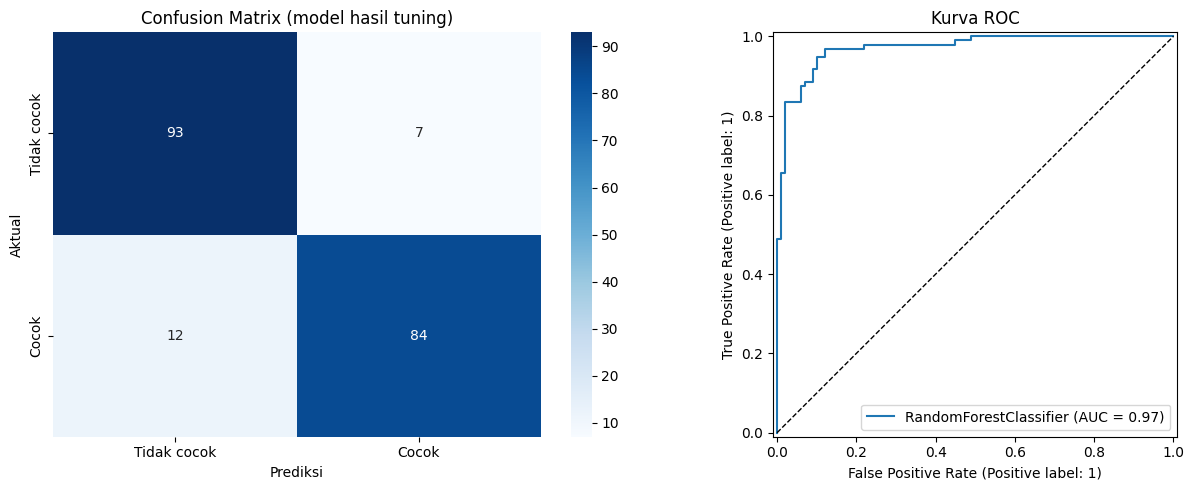

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Tidak cocok", "Cocok"],
            yticklabels=["Tidak cocok", "Cocok"])
axes[0].set_title("Confusion Matrix (model hasil tuning)")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Aktual")

RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("Kurva ROC")

plt.tight_layout()
plt.show()

## 11. Feature Importance

/tmp/ipykernel_15145/3890848654.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, y="feature", x="importance", palette="viridis")


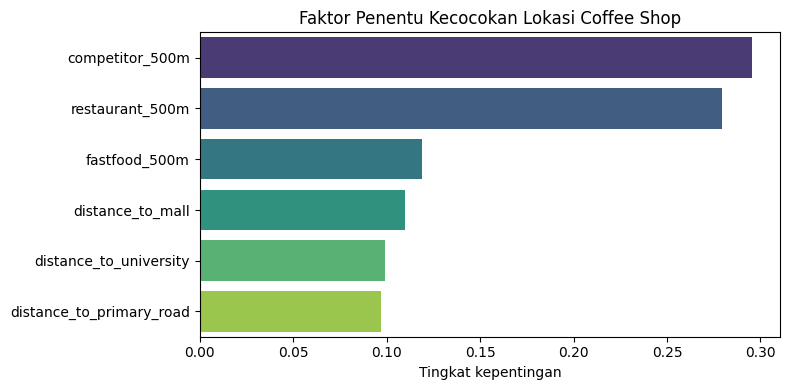

,feature,importance
0,competitor_500m,0.295704
1,restaurant_500m,0.279629
2,fastfood_500m,0.119099
3,distance_to_mall,0.109630
4,distance_to_university,0.099029
5,distance_to_primary_road,0.096908


In [25]:
importance = (
    pd.DataFrame({"feature": FEATURES, "importance": best_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(8, 4))
sns.barplot(data=importance, y="feature", x="importance", palette="viridis")
plt.title("Faktor Penentu Kecocokan Lokasi Coffee Shop")
plt.xlabel("Tingkat kepentingan")
plt.ylabel("")
plt.tight_layout()
plt.show()

importance

## 12. Explainability dengan SHAP


/tmp/ipykernel_15145/3237437862.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_test, feature_names=FEATURES, show=False)


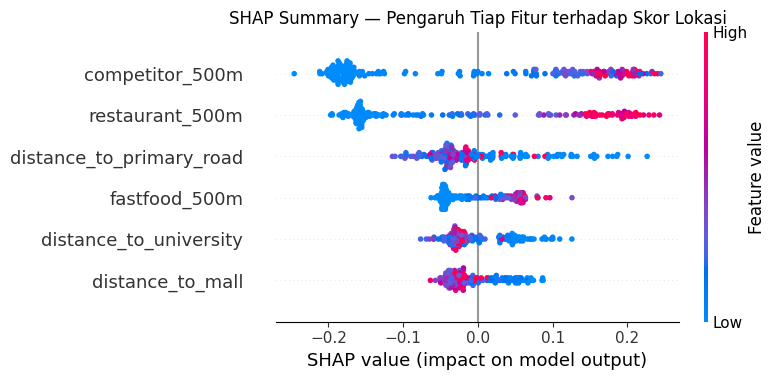

In [26]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Ambil nilai SHAP untuk kelas positif (kelas 1)
sv = shap_values[:, :, 1] if np.array(shap_values).ndim == 3 else shap_values

shap.summary_plot(sv, X_test, feature_names=FEATURES, show=False)
plt.title("SHAP Summary — Pengaruh Tiap Fitur terhadap Skor Lokasi")
plt.tight_layout()
plt.show()

/tmp/ipykernel_15145/2370980895.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_test, feature_names=FEATURES, plot_type="bar", show=False)


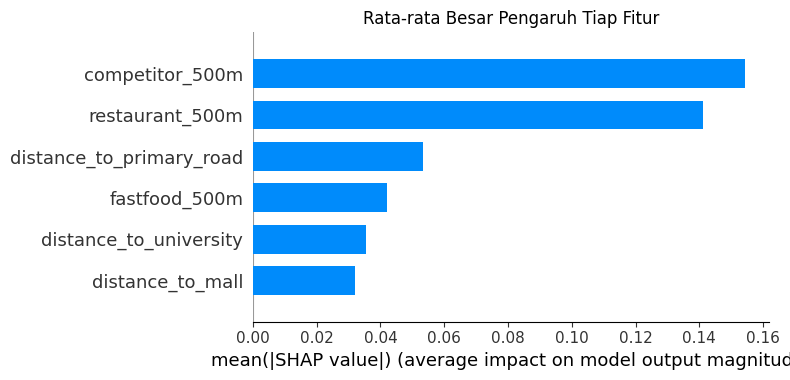

In [27]:
shap.summary_plot(sv, X_test, feature_names=FEATURES, plot_type="bar", show=False)
plt.title("Rata-rata Besar Pengaruh Tiap Fitur")
plt.tight_layout()
plt.show()

### Interpretasi Lebih Dalam — SHAP Dependence Plot

Bar chart sebelumnya baru menampilkan seberapa penting suatu fitur, belum memperlihatkan bagaimana fitur tersebut memengaruhi prediksi. Plot di bawah melengkapi analisis tersebut untuk dua fitur utama: jarak ke kampus dan kepadatan kompetitor.

> **Karakterisitik Fitur competitor_500m:** Nilainya diukur dari kedekatan ke kafe eksisting. Akibatnya, model secara alami lebih menyukai area yang sudah "teruji" ramai kafe daripada area blue ocean yang masih kosong.

>**Fungsi Plot:** Dependence plot ini menguji apakah hubungan tersebut murni berbanding lurus (makin ramai makin bagus) atau ada batas jenuh (tipping point) di mana kompetitor yang terlalu padat mulai berdampak negatif.


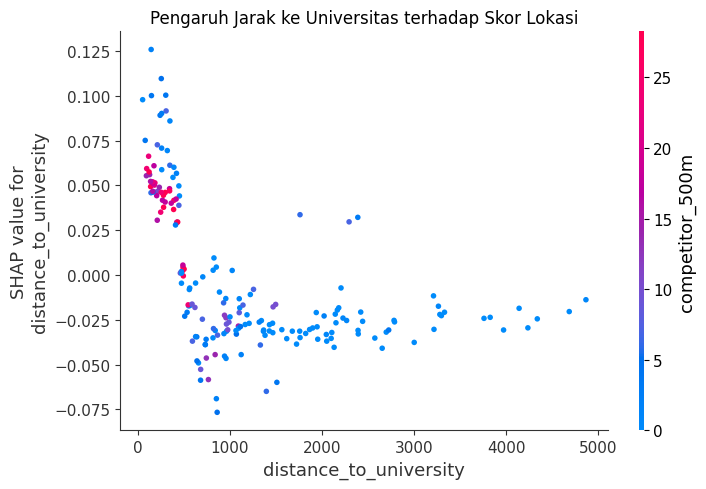

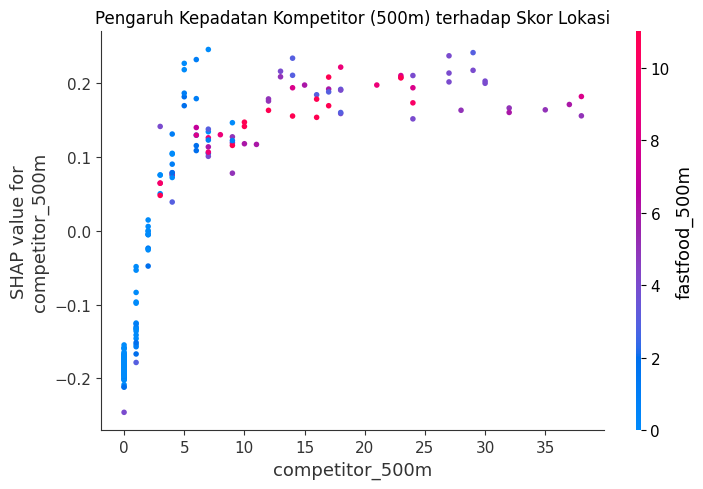

In [28]:
shap.dependence_plot("distance_to_university", sv, X_test, feature_names=FEATURES, show=False)
plt.title("Pengaruh Jarak ke Universitas terhadap Skor Lokasi")
plt.tight_layout()
plt.show()

shap.dependence_plot("competitor_500m", sv, X_test, feature_names=FEATURES, show=False)
plt.title("Pengaruh Kepadatan Kompetitor (500m) terhadap Skor Lokasi")
plt.tight_layout()
plt.show()


## 13. Prediksi ke Seluruh Wilayah Bandung

In [29]:
# Bangun grid titik setiap 300 meter di dalam wilayah Bandung
SPACING = 300  # meter

xs = np.arange(minx, maxx, SPACING)
ys = np.arange(miny, maxy, SPACING)

grid_points = [Point(x, y) for x in xs for y in ys]
grid_gdf = gpd.GeoDataFrame(geometry=grid_points, crs=f"EPSG:{CRS_METRIC}")

# Sisakan hanya titik yang berada di dalam batas wilayah
grid_gdf = grid_gdf[grid_gdf.geometry.within(polygon)].reset_index(drop=True)

print("Jumlah titik kandidat lokasi:", len(grid_gdf))

Jumlah titik kandidat lokasi: 1860


In [30]:
# Hitung fitur untuk seluruh grid (memakai fungsi yang sama dengan training)
grid_gdf = build_features(grid_gdf, is_cafe=False)

grid_gdf[FEATURES].describe()

,competitor_500m,restaurant_500m,fastfood_500m,distance_to_university,distance_to_mall,distance_to_primary_road
count,1860.000000,1860.000000,1860.000000,1860.000000,1860.000000,1860.000000
mean,2.218817,4.747849,1.120430,1451.341252,1632.492300,562.124103
std,4.890734,9.558707,2.726064,1098.363943,926.116645,599.798078
min,0.000000,0.000000,0.000000,9.569343,24.653362,0.269774
25%,0.000000,0.000000,0.000000,613.704971,871.929492,147.132646
50%,0.000000,0.000000,0.000000,1098.627251,1556.521005,374.368405
75%,2.000000,4.000000,1.000000,2100.248375,2268.302249,738.311350
max,42.000000,59.000000,20.000000,5425.983444,4808.503905,3800.192860


count    1860.000000
mean        0.234773
std         0.281620
min         0.000979
25%         0.036764
50%         0.093083
75%         0.339170
max         1.000000
Name: skor_kecocokan, dtype: float64


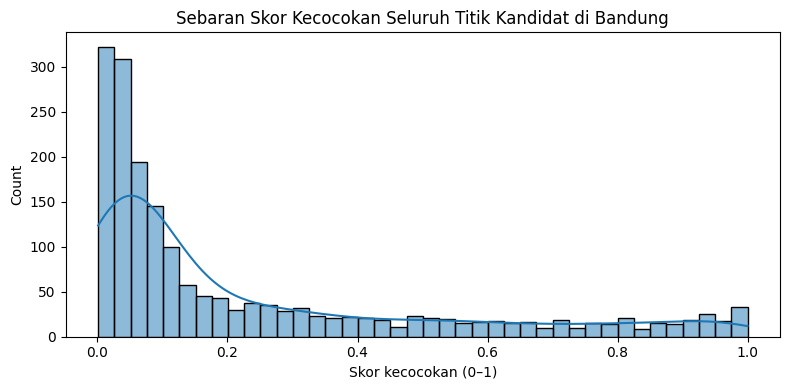

In [31]:
# Prediksi skor kecocokan (probabilitas kelas 1)
grid_gdf["skor_kecocokan"] = best_model.predict_proba(grid_gdf[FEATURES])[:, 1]

print(grid_gdf["skor_kecocokan"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(grid_gdf["skor_kecocokan"], bins=40, kde=True)
plt.title("Sebaran Skor Kecocokan Seluruh Titik Kandidat di Bandung")
plt.xlabel("Skor kecocokan (0–1)")
plt.tight_layout()
plt.show()

### Menyaring rekomendasi
Walau memiliki skor titik, jika titiknya berjarak < 150 m dari
cafe existing maka akan disaring keluar dari daftar rekomendasi.

In [32]:
grid_gdf["jarak_cafe_terdekat"] = distance_to_nearest(grid_gdf.geometry, cafes)

# Kandidat = skor tinggi TAPI belum ada cafe di sekitarnya
kandidat = grid_gdf[grid_gdf["jarak_cafe_terdekat"] >= 150].copy()
kandidat = kandidat.sort_values("skor_kecocokan", ascending=False)

TOP_N = 10
# Top-N dengan jarak minimum antar rekomendasi (spatial diversity)
MIN_JARAK_ANTAR_REKOMENDASI = 1000  # meter

terpilih = []
for idx, row in kandidat.iterrows():
    if all(row.geometry.distance(t.geometry) >= MIN_JARAK_ANTAR_REKOMENDASI
           for t in terpilih):
        terpilih.append(row)
    if len(terpilih) == TOP_N:
        break

top_lokasi = gpd.GeoDataFrame(terpilih, crs=kandidat.crs)

top_latlon = top_lokasi.to_crs(epsg=CRS_LATLON)
top_lokasi["longitude"] = top_latlon.geometry.x.values
top_lokasi["latitude"]  = top_latlon.geometry.y.values

print(f"Top {len(top_lokasi)} lokasi, terpisah minimal {MIN_JARAK_ANTAR_REKOMENDASI} m")
top_lokasi[["latitude", "longitude", "skor_kecocokan"] + FEATURES].reset_index(drop=True)

Top 10 lokasi, terpisah minimal 1000 m


,latitude,longitude,skor_kecocokan,competitor_500m,restaurant_500m,fastfood_500m,distance_to_university,distance_to_mall,distance_to_primary_road
0,-6.902413,107.615766,0.989050,22,40,5,244.151672,485.017572,117.840419
1,-6.913301,107.607687,0.972640,23,29,8,395.854780,423.910341,83.936311
2,-6.894383,107.596732,0.964846,8,27,4,675.106822,571.013053,43.607519
3,-6.902487,107.602202,0.953700,7,29,0,395.450106,621.583725,24.478406
4,-6.956159,107.700166,0.944327,20,42,12,1664.577679,264.262950,1498.736294
5,-6.894324,107.607583,0.941526,19,38,16,196.143559,259.846021,384.908502
6,-6.880710,107.618360,0.928262,13,30,3,482.976020,1706.722863,232.663826
7,-6.916071,107.596851,0.919671,5,22,1,1129.357511,296.493406,32.172972
8,-6.934899,107.624084,0.908620,5,16,4,728.404202,212.156203,56.645025
9,-6.915863,107.634830,0.895789,4,7,2,393.905274,100.741256,39.961399


In [33]:
sv_top = explainer.shap_values(top_lokasi[FEATURES])
sv_top = sv_top[:, :, 1] if np.array(sv_top).ndim == 3 else sv_top

LABEL_ID = {
    "competitor_500m": "jumlah kompetitor sekitar",
    "restaurant_500m": "kepadatan restoran sekitar",
    "fastfood_500m": "kepadatan fast food sekitar",
    "distance_to_university": "jarak ke kampus",
    "distance_to_mall": "jarak ke mall",
    "distance_to_primary_road": "jarak ke jalan utama",
}

print("=== ALASAN REKOMENDASI ===\n")
for i in range(len(top_lokasi)):
    row = top_lokasi.iloc[i]
    kontrib = pd.Series(sv_top[i], index=FEATURES).sort_values(key=abs, ascending=False)
    alasan = []
    for fitur, nilai in kontrib.head(3).items():
        arah = "mendukung" if nilai > 0 else "mengurangi"
        alasan.append(f"{LABEL_ID[fitur]} ({row[fitur]:.0f}) {arah}")
    print(f"#{i+1}  ({row['latitude']:.5f}, {row['longitude']:.5f})  skor {row['skor_kecocokan']:.2f}")
    print("     " + "; ".join(alasan))
    print()

=== ALASAN REKOMENDASI ===

#1  (-6.90241, 107.61577)  skor 0.99
     jumlah kompetitor sekitar (22) mendukung; kepadatan restoran sekitar (40) mendukung; kepadatan fast food sekitar (5) mendukung

#2  (-6.91330, 107.60769)  skor 0.97
     jumlah kompetitor sekitar (23) mendukung; kepadatan restoran sekitar (29) mendukung; kepadatan fast food sekitar (8) mendukung

#3  (-6.89438, 107.59673)  skor 0.96
     kepadatan restoran sekitar (27) mendukung; jumlah kompetitor sekitar (8) mendukung; jarak ke jalan utama (44) mendukung

#4  (-6.90249, 107.60220)  skor 0.95
     kepadatan restoran sekitar (29) mendukung; jumlah kompetitor sekitar (7) mendukung; jarak ke jalan utama (24) mendukung

#5  (-6.95616, 107.70017)  skor 0.94
     kepadatan restoran sekitar (42) mendukung; jumlah kompetitor sekitar (20) mendukung; kepadatan fast food sekitar (12) mendukung

#6  (-6.89432, 107.60758)  skor 0.94
     jumlah kompetitor sekitar (19) mendukung; kepadatan restoran sekitar (38) mendukung; jarak ke

## 14. Peta Interaktif

In [34]:
grid_latlon = grid_gdf.to_crs(epsg=CRS_LATLON)
center = [grid_latlon.geometry.y.mean(), grid_latlon.geometry.x.mean()]

m = folium.Map(location=center, zoom_start=12, tiles="cartodbpositron")

# Heatmap skor seluruh grid
for _, row in grid_latlon.iterrows():
    skor = row["skor_kecocokan"]
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3,
        color=None,
        fill=True,
        fill_color="#d73027" if skor > 0.7 else "#fc8d59" if skor > 0.5 else "#91bfdb",
        fill_opacity=0.25 + 0.55 * skor,
        weight=0,
    ).add_to(m)

# Tanda Top-N rekomendasi
for i, (_, row) in enumerate(top_lokasi.iterrows(), start=1):
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=folium.Popup(
            f"<b>Rekomendasi #{i}</b><br>"
            f"Skor: {row['skor_kecocokan']:.2f}<br>"
            f"Kompetitor 500m: {row['competitor_500m']:.0f}<br>"
            f"Restoran 500m: {row['restaurant_500m']:.0f}<br>"
            f"Jarak kampus: {row['distance_to_university']:.0f} m<br>"
            f"Jarak mall: {row['distance_to_mall']:.0f} m<br>"
            f"Jarak jalan utama: {row['distance_to_primary_road']:.0f} m",
            max_width=260
        ),
        icon=folium.Icon(color="darkgreen", icon="star"),
    ).add_to(m)

m

## 15. Limitasi & Rencana Pengembangan

**Keterbatasan Utama Data & Metode:**

> * Ketergantungan Data OSM: Terbatas pada kategori coffee shop formal dan kelengkapan peta wilayah pinggiran. Sifat data live OSM juga membuat hasil analisis bersifat snapshot.

> * Belum Memuat Variabel Finansial & Ekonomi: Belum memperhitungkan harga sewa, daya beli (BPS), foot traffic nyata, dan belum divalidasi terhadap data omzet aktual.
(Catatan: Isu pseudo-absence dan spatial autocorrelation telah dirampungkan pada Seksi 1 & 10d).

**Rencana Pengembangan Lanjutan:**

* v2 (Indikator Tambahan): Memasukkan variabel BPS (daya beli/penduduk) dan bobot jaringan jalan OSM sebagai proksi keramaian.

* v3 (Validasi & Skalabilitas): Melakukan backtesting pada lokasi kafe eksisting yang terbukti ramai, serta menguji transferabilitas model ke Kota Jakarta dan Surabaya.

In [35]:
import joblib

joblib.dump(best_model, "smartsite_model.pkl")
dataset.to_csv("smartsite_dataset.csv", index=False)
top_lokasi[["latitude", "longitude", "skor_kecocokan"] + FEATURES].to_csv(
    "smartsite_top_lokasi.csv", index=False
)
m.save("smartsite_peta.html")

print("Tersimpan:")
print(" - smartsite_model.pkl")
print(" - smartsite_dataset.csv")
print(" - smartsite_top_lokasi.csv")
print(" - smartsite_peta.html")

Tersimpan:
 - smartsite_model.pkl
 - smartsite_dataset.csv
 - smartsite_top_lokasi.csv
 - smartsite_peta.html
